# Event-study: цены скинов CS2 при переходе коллекций в limited

**Гипотеза.** Когда коллекция уходит в limited (исключается из drop pool / Armory), скины fixed-supply переходят в режим scarcity. На low-grade скинах (Consumer Grade в Shattered Web/Broken Fang; Industrial Grade в Graphic Design) это должно давать отчётливый ценовой импульс с локальным пиком и всплеском волатильности.

**Дизайн.**
- 6 коллекций: Norse, St. Marc, Canals (Shattered Web, limited 2020-03-31), Havoc, Control (Broken Fang, limited 2021-04-30), Graphic Design (Armory, limited 2025-10-01).
- На коллекцию: 5 low-grade скинов в Field-Tested.
- Окно событий: t ∈ [-30, +90] календарных дней от даты перехода в limited.
- Индекс цены: композит по 5 скинам коллекции (геометрическое среднее нормированных цен; база = 100 на t=0). Аналог Case-Shiller на малой выборке.
- Волатильность: rolling std дневных лог-доходностей, окно 7 дней.
- Пик: argmax композитного индекса и argmax волатильности на интервале [-30, +90].

**Источник данных.** Steam Market price history endpoint (`/market/pricehistory/`), аутентификация через `steamLoginSecure` cookie. Возвращает дневные средневзвешенные цены и объёмы.

**Ограничения, которые надо держать в голове.**
1. Steam отдаёт максимум 6 месяцев почасовых, дальше дневные - для окна [-30, +90] это OK.
2. Цена номинирована в твоей валюте кошелька (определяется по cookie). Для cross-collection сопоставимости работаем в индексах, не в абсолютных значениях.
3. Низкая ликвидность low-grade скинов: на отдельных днях может быть 0 продаж - заполняем LOCF до 3 дней, далее NaN.


In [ ]:
# === В Colab расскоментировать ===
# !pip install -q requests pandas numpy matplotlib seaborn scipy


In [ ]:
import os
import re
import json
import time
import math
import warnings
from datetime import datetime, timedelta
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from urllib.parse import quote

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 140,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

CACHE_DIR = Path('./cs2_cache')
CACHE_DIR.mkdir(exist_ok=True)
print(f'Кэш: {CACHE_DIR.resolve()}')


Кэш: /content/cs2_cache


## 1. Конфигурация: даты событий, список скинов, параметры

`STEAM_LOGIN_SECURE` - cookie из браузера. Получить:
1. Залогинься на steamcommunity.com
2. F12 -> Application -> Cookies -> steamcommunity.com -> steamLoginSecure -> Value
3. Скопировать целиком (длинная строка с %, не сокращать)


In [ ]:
# ВСТАВЬ СЮДА свой steamLoginSecure cookie (без кавычек внутри)
STEAM_LOGIN_SECURE = ""

# Country/currency определяются автоматически из cookie, но можно форсировать
# country='RU' -> рубли, country='US' -> USD. Меняем только если нужно перевести в другую валюту.
STEAM_COUNTRY = 'US'
STEAM_CURRENCY = 1  # 1=USD, 5=RUB, 3=EUR

# Окно событий (в днях от limit date)
PRE_DAYS, POST_DAYS = 30, 90

# Волатильность - окно rolling std (в днях)
VOL_WINDOW = 7

# Wear
WEAR = 'Field-Tested'

# --- Параметры фиксов (см. разделы 3 и 6) ---
WINSOR_PCT   = 0.01  # винзоризация лог-доходностей по 1-му/99-му перцентилю (на скин)
SMOOTH_WINDOW = 5    # окно скользящей медианы для поиска пика (убивает однодневные иглы)
MIN_DAILY_VOL = 3    # дни с суммарным объёмом коллекции < порога исключаются из поиска экстремума
VOL_PEAK_WINDOW = (0, 14)  # окно поиска event-локального пика волатильности (дни от t=0)

# Анонсы удаления. Если рынок реагирует на анонс раньше фактического limited,
# событие честнее якорить на анонс (база=100 тогда на доанонсной цене, а не на разогретой).
ANNOUNCE_DATES = {
    'Graphic Design': pd.Timestamp('2025-09-10'),  # анонс удаления из Armory
}
USE_ANNOUNCE_AS_EVENT = True  # True -> t=0 на анонсе там, где он известен; False -> на фактическом удалении

# Даты ухода в limited
EVENT_DATES = {
    'Norse':         pd.Timestamp('2020-03-31'),
    'St. Marc':      pd.Timestamp('2020-03-31'),
    'Canals':        pd.Timestamp('2020-03-31'),
    'Havoc':         pd.Timestamp('2021-04-30'),
    'Control':       pd.Timestamp('2021-04-30'),
    'Graphic Design':pd.Timestamp('2025-10-01'),
}

# Эффективная дата события (якорь t=0): анонс там, где известен и включён флаг, иначе фактическое удаление
EVENT_DATES_EFF = {
    coll: (ANNOUNCE_DATES.get(coll, dt) if USE_ANNOUNCE_AS_EVENT else dt)
    for coll, dt in EVENT_DATES.items()
}
# Вторичный маркер: event-day фактического удаления относительно эффективного якоря.
# Для GD при якоре на анонс removal окажется на +21 - рисуем бледной линией на графиках.
SECONDARY_MARKERS = {
    coll: int((EVENT_DATES[coll] - EVENT_DATES_EFF[coll]).days)
    for coll in EVENT_DATES if EVENT_DATES[coll] != EVENT_DATES_EFF[coll]
}
if SECONDARY_MARKERS:
    print('Вторичные маркеры (фактическое удаление, event-day):', SECONDARY_MARKERS)

# Короткое имя -> полное имя коллекции в базе ByMykel CSGO-API
COLLECTION_FULLNAME = {
    'Norse':          'The Norse Collection',
    'St. Marc':       'The St. Marc Collection',
    'Canals':         'The Canals Collection',
    'Havoc':          'The Havoc Collection',
    'Control':        'The Control Collection',
    'Graphic Design': 'The Graphic Design Collection',
}

# SKINS строится автоматически в следующей ячейке (раздел 1.1) - имена не угадываем руками.
SKINS = {}
print(f'{len(EVENT_DATES)} коллекций, wear={WEAR}. Состав скинов соберём из базы ниже.')


Вторичные маркеры (фактическое удаление, event-day): {'Graphic Design': 21}
6 коллекций, wear=Field-Tested. Состав скинов соберём из базы ниже.


### 1.1 Автосбор состава скинов из базы (без ручного ввода имён)

Тянем `ByMykel/CSGO-API` (открытая база всех скинов с коллекцией и грейдом), фильтруем по нашим коллекциям и берём **низший доступный грейд**: Consumer Grade везде, кроме Graphic Design, где низшая ступень - Industrial Grade. Имена приходят ровно в формате Steam `market_hash_name`, поэтому 500-х из-за опечаток больше не будет.

Это заодно делает ноутбук расширяемым: чтобы добавить placebo-коллекцию (раздел 9), достаточно дописать строку в `EVENT_DATES` и `COLLECTION_FULLNAME`.


In [ ]:
SKINS_DB_URL = 'https://raw.githubusercontent.com/ByMykel/CSGO-API/main/public/api/en/skins.json'
RARITY_ORDER = ['Consumer Grade', 'Industrial Grade', 'Mil-Spec Grade',
                'Restricted', 'Classified', 'Covert']


def build_skins_from_db(collection_fullname: Dict[str, str]) -> Dict[str, List[str]]:
    '''Возвращает {short_name -> [market_hash_name низшего грейда]}.'''
    import urllib.request
    req = urllib.request.Request(SKINS_DB_URL, headers={'User-Agent': 'Mozilla/5.0'})
    db = json.loads(urllib.request.urlopen(req, timeout=60).read())

    # collection_full -> rarity -> set(names)
    from collections import defaultdict
    table = defaultdict(lambda: defaultdict(set))
    wanted = set(collection_fullname.values())
    for s in db:
        rar = (s.get('rarity') or {}).get('name', '?')
        nm = (s.get('name') or '').split(' (')[0].strip()  # отрезаем wear
        for c in (s.get('collections') or []):
            cn = c.get('name', '')
            if cn in wanted:
                table[cn][rar].add(nm)

    out = {}
    for short, full in collection_fullname.items():
        chosen_rarity, names = None, []
        for r in RARITY_ORDER:
            if table[full].get(r):
                chosen_rarity = r
                names = sorted(table[full][r])
                break
        out[short] = names
        print(f'{short:16s} <- {chosen_rarity or "НЕ НАЙДЕНО":15s}: {len(names)} скинов')
        for n in names:
            print(f'      {n}')
    return out


SKINS = build_skins_from_db(COLLECTION_FULLNAME)
n_total = sum(len(v) for v in SKINS.values())
print(f'\nИтого {n_total} скинов в {len(SKINS)} коллекциях')


Norse            <- Consumer Grade : 5 скинов
      FAMAS | Night Borre
      Galil AR | Tornado
      MP7 | Scorched
      SG 553 | Barricade
      SSG 08 | Red Stone
St. Marc         <- Consumer Grade : 5 скинов
      M249 | Jungle
      MAC-10 | Surfwood
      MP5-SD | Bamboo Garden
      PP-Bizon | Seabird
      Sawed-Off | Jungle Thicket
Canals           <- Consumer Grade : 5 скинов
      AUG | Navy Murano
      CZ75-Auto | Indigo
      Negev | Boroque Sand
      R8 Revolver | Canal Spray
      SCAR-20 | Stone Mosaico
Havoc            <- Consumer Grade : 5 скинов
      Dual Berettas | Heist
      M249 | Predator
      PP-Bizon | Death Rattle
      Sawed-Off | Clay Ambush
      Tec-9 | Phoenix Chalk
Control          <- Consumer Grade : 5 скинов
      AUG | Surveillance
      CZ75-Auto | Jungle Dashed
      MP9 | Army Sheen
      P250 | Forest Night
      XM1014 | Charter
Graphic Design   <- Industrial Grade: 6 скинов
      FAMAS | Halftone Wash
      Galil AR | NV
      M249 | Spec

## 2. Steam Market data acquisition

Endpoint: `https://steamcommunity.com/market/pricehistory/?country=US&currency=1&appid=730&market_hash_name=<name>`

Возвращает JSON `{success: true, price_prefix, price_suffix, prices: [[date_str, price, volume_str], ...]}`. Авторизация через cookie обязательна, иначе `403`.

Steam агрегирует в **почасовые** свечи за последние 30 дней, потом **дневные** до 1 года назад, потом **недельные**. Для окна [-30, +90] нам почти всегда хватит дневных. Для свежей Graphic Design часть данных в почасовых - аггрегируем до дневных вручную.

**Rate limiting.** Steam не публикует лимиты, но эмпирически: ~20 запросов/мин безопасно, >40 - 429. Ставим 3 сек между запросами и retry с backoff.


In [ ]:
def market_hash_to_url(hash_name: str, wear: str = WEAR) -> str:
    '''Полное имя для market_hash_name: <weapon> | <skin> (<wear>)'''
    full = f'{hash_name} ({wear})'
    return f'https://steamcommunity.com/market/pricehistory/?country={STEAM_COUNTRY}&currency={STEAM_CURRENCY}&appid=730&market_hash_name={quote(full)}'


def fetch_price_history(hash_name: str, wear: str = WEAR,
                         force: bool = False, sleep: float = 3.0) -> Optional[pd.DataFrame]:
    '''Достаёт price history из Steam Market. Кэширует на диск.'''
    safe = re.sub(r'[^a-zA-Z0-9]+', '_', f'{hash_name}_{wear}').strip('_')
    cache_path = CACHE_DIR / f'{safe}.json'

    if cache_path.exists() and not force:
        with open(cache_path, 'r', encoding='utf-8') as f:
            payload = json.load(f)
    else:
        url = market_hash_to_url(hash_name, wear)
        headers = {
            'User-Agent': 'Mozilla/5.0',
            'Cookie': f'steamLoginSecure={STEAM_LOGIN_SECURE}',
        }
        for attempt in range(3):
            try:
                r = requests.get(url, headers=headers, timeout=20)
                if r.status_code == 200:
                    payload = r.json()
                    if payload.get('success'):
                        with open(cache_path, 'w', encoding='utf-8') as f:
                            json.dump(payload, f)
                        time.sleep(sleep)
                        break
                    else:
                        print(f'  [!] success=false: {hash_name}')
                        return None
                elif r.status_code == 429:
                    print(f'  [!] 429 rate limit, sleep {30 * (attempt+1)}s')
                    time.sleep(30 * (attempt + 1))
                else:
                    print(f'  [!] HTTP {r.status_code}: {hash_name}')
                    return None
            except Exception as e:
                print(f'  [!] {hash_name}: {e}')
                time.sleep(5)
        else:
            return None

    # Парсинг
    raw = payload.get('prices', [])
    if not raw:
        return None
    df = pd.DataFrame(raw, columns=['date_raw', 'price', 'volume'])
    df['price'] = pd.to_numeric(df['price'])
    df['volume'] = pd.to_numeric(df['volume'])
    # Steam format: 'Nov 01 2019 01: +0' -> часовая отметка
    df['ts'] = pd.to_datetime(df['date_raw'], format='%b %d %Y %H: +0', errors='coerce')
    df = df.dropna(subset=['ts']).drop(columns=['date_raw']).sort_values('ts').reset_index(drop=True)
    df['hash_name'] = hash_name
    return df


def probe_skin(hash_name: str, wear: str = WEAR) -> bool:
    '''Быстрая проверка: есть ли такой скин на маркете.'''
    df = fetch_price_history(hash_name, wear, sleep=2.0)
    if df is None or len(df) == 0:
        return False
    print(f'  ok  {hash_name}: {len(df)} наблюдений, {df.ts.min().date()} -> {df.ts.max().date()}')
    return True


if not STEAM_LOGIN_SECURE:
    print('⚠ Заполни STEAM_LOGIN_SECURE в ячейке выше перед запуском.')


### 2.1 Валидация имён скинов

Прогоняем все имена через probe.


In [ ]:
# Запускать после того, как вставлен cookie
if STEAM_LOGIN_SECURE:
    failed = {}
    for coll, skins in SKINS.items():
        print(f'\n=== {coll} ===')
        bad = []
        for s in skins:
            if not probe_skin(s):
                bad.append(s)
        if bad:
            failed[coll] = bad
    if failed:
        print('\n⚠ НЕНАЙДЕННЫЕ СКИНЫ - поправь имена в SKINS:')
        for coll, bad in failed.items():
            for s in bad:
                print(f'  {coll}: {s!r}')
    else:
        print('\n✓ Все скины найдены')
else:
    print('Сначала заполни STEAM_LOGIN_SECURE')



=== Norse ===
  ok  FAMAS | Night Borre: 2446 наблюдений, 2019-11-19 -> 2026-05-30
  ok  Galil AR | Tornado: 2464 наблюдений, 2019-11-18 -> 2026-05-30
  ok  MP7 | Scorched: 2432 наблюдений, 2019-11-19 -> 2026-05-30
  ok  SG 553 | Barricade: 2407 наблюдений, 2019-11-18 -> 2026-05-30
  ok  SSG 08 | Red Stone: 2502 наблюдений, 2019-11-18 -> 2026-05-30

=== St. Marc ===
  ok  M249 | Jungle: 2440 наблюдений, 2019-11-19 -> 2026-05-29
  ok  MAC-10 | Surfwood: 2423 наблюдений, 2019-11-18 -> 2026-05-29
  ok  MP5-SD | Bamboo Garden: 2416 наблюдений, 2019-11-18 -> 2026-05-29
  ok  PP-Bizon | Seabird: 2415 наблюдений, 2019-11-19 -> 2026-05-30
  ok  Sawed-Off | Jungle Thicket: 2396 наблюдений, 2019-11-18 -> 2026-05-30

=== Canals ===
  ok  AUG | Navy Murano: 2461 наблюдений, 2019-11-19 -> 2026-05-30
  ok  CZ75-Auto | Indigo: 2469 наблюдений, 2019-11-19 -> 2026-05-29
  ok  Negev | Boroque Sand: 2365 наблюдений, 2019-11-19 -> 2026-05-29
  ok  R8 Revolver | Canal Spray: 2409 наблюдений, 2019-11-19 ->

### 2.2 Полная загрузка истории

Тянем всю историю по каждому скину (Steam отдаёт от листинга до сегодня). Кэш на диске; повторный запуск ноутбука инстант.


In [ ]:
def load_all_skins(skins_dict: Dict[str, List[str]]) -> Dict[str, pd.DataFrame]:
    '''Возвращает {(collection, hash_name) -> df с колонками ts, price, volume}'''
    out = {}
    for coll, skins in skins_dict.items():
        for s in skins:
            df = fetch_price_history(s)
            if df is not None and len(df) > 0:
                out[(coll, s)] = df
            else:
                print(f'  [skip] {coll} / {s}')
    return out


raw_data = load_all_skins(SKINS)
print(f'\nЗагружено: {len(raw_data)} скинов')



Загружено: 31 скинов


## 3. Очистка и агрегация до дневных

Steam отдаёт почасовые свечи в недавнем периоде. Приводим всё к дневной частоте: средневзвешенная по объёму цена + сумма объёмов.

Дальше:
- Forward-fill цены на дни без сделок (LOCF, максимум 3 дня).
- Лог-доходности: `r_t = log(P_t / P_{t-1})`.
- **Винзоризация** лог-доходностей по 1-му/99-му перцентилю (параметр `WINSOR_PCT`) - это фикс: на тонких рядах одна аномальная сделка (или глитч прайс-хистори) давала иглу в rolling-волатильности с усилением до 8x. Клиппинг хвостов убирает артефакт, не трогая нормальную динамику.
- Rolling волатильность: `vol_t = std(винзоризованных r) на окне VOL_WINDOW`.


In [ ]:
def to_daily(df: pd.DataFrame) -> pd.DataFrame:
    '''Часовые -> дневные, средневзвешенные по объёму.'''
    if df is None or len(df) == 0:
        return pd.DataFrame()
    df = df.copy()
    df['date'] = df['ts'].dt.normalize()
    df['pv'] = df['price'] * df['volume']
    daily = df.groupby('date').agg(
        price=('pv', 'sum'),
        volume=('volume', 'sum')
    ).reset_index()
    # Средневзвешенная: sum(p*v) / sum(v); если volume=0 (бывает редко), берём simple mean
    raw_mean = df.groupby('date')['price'].mean().values
    daily['price'] = np.where(daily['volume'] > 0, daily['price'] / daily['volume'].replace(0, np.nan), raw_mean)
    return daily.sort_values('date').reset_index(drop=True)


def add_returns_vol(df: pd.DataFrame, vol_window: int = VOL_WINDOW,
                    winsor_pct: float = WINSOR_PCT) -> pd.DataFrame:
    '''Лог-доходности (винзоризованные) + rolling std.'''
    df = df.copy().sort_values('date').reset_index(drop=True)
    # LOCF на пропусках до 3 дней
    df = df.set_index('date')
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq='D')
    df = df.reindex(full_idx)
    df['price'] = df['price'].ffill(limit=3)
    df['volume'] = df['volume'].fillna(0)
    df.index.name = 'date'
    df = df.reset_index()
    df['log_return'] = np.log(df['price'] / df['price'].shift(1))
    # ФИКС: винзоризация хвостов лог-доходностей, чтобы одна аномальная сделка
    # не раздувала rolling-волатильность (артефактные иглы в тонких рядах).
    r = df['log_return']
    if winsor_pct and r.notna().sum() > 10:
        lo, hi = r.quantile(winsor_pct), r.quantile(1 - winsor_pct)
        df['log_return_w'] = r.clip(lo, hi)
    else:
        df['log_return_w'] = r
    df['vol'] = df['log_return_w'].rolling(vol_window, min_periods=max(3, vol_window // 2)).std()
    return df


daily_data = {}
for key, df in raw_data.items():
    d = to_daily(df)
    d = add_returns_vol(d)
    daily_data[key] = d

print(f'Готово: {len(daily_data)} дневных рядов')

# Превью одного скина
sample_key = list(daily_data.keys())[0]
print(f'\nПример - {sample_key[0]} / {sample_key[1]}:')
print(daily_data[sample_key].tail(10))


Готово: 31 дневных рядов

Пример - Norse / FAMAS | Night Borre:
           date        price  volume  log_return  log_return_w       vol
2375 2026-05-21  6755.708750     4.0   -0.084517     -0.084517  0.038227
2376 2026-05-22  7371.982200     5.0    0.087299      0.087299  0.052163
2377 2026-05-23  7371.982200     0.0    0.000000      0.000000  0.051627
2378 2026-05-24  6730.756667     3.0   -0.090999     -0.090999  0.061996
2379 2026-05-25  6730.756667     0.0    0.000000      0.000000  0.062147
2380 2026-05-26  6730.756667     0.0    0.000000      0.000000  0.060290
2381 2026-05-27  7081.756667     3.0    0.050834      0.050834  0.065102
2382 2026-05-28  7081.756667     0.0    0.000000      0.000000  0.055028
2383 2026-05-29  5813.081750     4.0   -0.197411     -0.197411  0.083440
2384 2026-05-30  6172.942000     2.0    0.060065      0.060065  0.090317


## 4. Event-time выравнивание и композитный индекс по коллекции

**Шаги:**
1. Для каждого скина считаем `event_day = (date - limit_date).days`.
2. Обрезаем по окну `[-PRE_DAYS, +POST_DAYS]`.
3. Нормализуем цену: `P_norm = P_t / P_{t=0} × 100` (база = 100 на день ухода в limited).
4. Композит коллекции = **геометрическое среднее** нормированных цен по 5 скинам (устойчиво к одному outlier-у; эквивалентно среднему лог-цен).
5. Композит волы = среднее `vol` по скинам (волатильность плохо логарифмировать; усреднение в уровнях нормально).

Геометрическое среднее предпочтительнее арифметического: цена в индексе - мультипликативная величина, и если один скин x2, а другой 0.5, мы хотим получить ~1, а не 1.25.

**Якорь события (`EVENT_DATES_EFF`).** Для большинства коллекций t=0 - дата фактического ухода в limited. Для Graphic Design рынок отреагировал на анонс (10.09.2025) за 3 недели до удаления (01.10.2025), поэтому при `USE_ANNOUNCE_AS_EVENT=True` GD якорится на анонс - иначе база=100 ставится на уже разогретую анонсом цену и пост-event рост занижается. Дата фактического удаления рисуется на графиках GD бледной линией (вторичный маркер на +21).


In [ ]:
def to_event_time(df: pd.DataFrame, event_date: pd.Timestamp,
                  pre: int = PRE_DAYS, post: int = POST_DAYS) -> pd.DataFrame:
    '''Добавляет event_day, режет окном, нормализует цену к event_day=0.'''
    df = df.copy()
    df['event_day'] = (df['date'] - event_date).dt.days
    df = df[(df['event_day'] >= -pre) & (df['event_day'] <= post)].copy()
    if len(df) == 0:
        return df
    # Якорная цена: ближайший непропущенный день к event_day=0 (предпочитаем <=0)
    candidates = df[df['event_day'] <= 0].dropna(subset=['price'])
    if len(candidates) == 0:
        candidates = df.dropna(subset=['price'])
        if len(candidates) == 0:
            return df.iloc[0:0]
    anchor_row = candidates.iloc[(candidates['event_day'] - 0).abs().argsort()].iloc[0]
    p0 = anchor_row['price']
    df['price_idx'] = df['price'] / p0 * 100.0
    return df


event_panels = {}  # collection -> dict(hash_name -> df with event_day, price_idx, vol)
for (coll, hash_name), df in daily_data.items():
    et = to_event_time(df, EVENT_DATES_EFF[coll])
    if len(et) > 0:
        event_panels.setdefault(coll, {})[hash_name] = et


def composite_index(coll: str) -> pd.DataFrame:
    '''Геометрический композит цен + усреднённая воля + суммарный объём по скинам коллекции.'''
    skins = event_panels.get(coll, {})
    if not skins:
        return pd.DataFrame()
    frames = []
    for hash_name, df in skins.items():
        sub = df[['event_day', 'price_idx', 'vol', 'volume']].rename(
            columns={'price_idx': f'p_{hash_name}', 'vol': f'v_{hash_name}',
                     'volume': f'vol_{hash_name}'}
        )
        frames.append(sub.set_index('event_day'))
    panel = pd.concat(frames, axis=1).sort_index()
    p_cols = [c for c in panel.columns if c.startswith('p_')]
    v_cols = [c for c in panel.columns if c.startswith('v_')]
    q_cols = [c for c in panel.columns if c.startswith('vol_')]
    # геом среднее = exp(mean(log(p)))
    log_p = np.log(panel[p_cols])
    panel['composite_price'] = np.exp(log_p.mean(axis=1, skipna=True))
    panel['n_skins_price'] = log_p.notna().sum(axis=1)
    panel['composite_vol'] = panel[v_cols].mean(axis=1, skipna=True)
    panel['n_skins_vol'] = panel[v_cols].notna().sum(axis=1)
    # ФИКС: суммарный дневной объём по коллекции (для volume-фильтра при поиске пика)
    panel['day_volume'] = panel[q_cols].sum(axis=1, skipna=True)
    # ФИКС: сглаженный композит (скользящая медиана) - по нему ищем пик, чтобы
    # однодневные иглы на тонких днях не выдавались за пик.
    panel = panel.reset_index()
    panel['composite_price_smooth'] = (
        panel['composite_price'].rolling(SMOOTH_WINDOW, center=True, min_periods=2).median()
    )
    panel['composite_vol_smooth'] = (
        panel['composite_vol'].rolling(SMOOTH_WINDOW, center=True, min_periods=2).median()
    )
    return panel


composites = {coll: composite_index(coll) for coll in EVENT_DATES if coll in event_panels}
for coll, c in composites.items():
    ns = len(SKINS.get(coll, []))
    print(f'{coll:18s} {len(c):3d} дней, скинов в индексе: '
          f'{c.n_skins_price.median():.0f}/{ns}, воля: {c.n_skins_vol.median():.0f}/{ns}')


Norse              121 дней, скинов в индексе: 5/5, воля: 5/5
St. Marc           121 дней, скинов в индексе: 5/5, воля: 5/5
Canals             121 дней, скинов в индексе: 5/5, воля: 5/5
Havoc              121 дней, скинов в индексе: 5/5, воля: 5/5
Control            121 дней, скинов в индексе: 5/5, воля: 5/5
Graphic Design     121 дней, скинов в индексе: 6/6, воля: 6/6


In [ ]:
def find_peaks(comp: pd.DataFrame, min_vol: int = MIN_DAILY_VOL) -> Dict[str, float]:
    '''Возвращает день и амплитуду пика цены/волы, фазу, vol amplification.
    Пики ищутся по сглаженному композиту с volume-фильтром; пик волы - только в VOL_PEAK_WINDOW.'''
    if len(comp) == 0:
        return {}
    liquid = comp[comp['day_volume'] >= min_vol].copy()
    if len(liquid) < 5:
        liquid = comp.copy()
    pser = liquid['composite_price_smooth']
    if pser.notna().any():
        pmax_idx = pser.idxmax()
        peak_price_day = int(liquid.loc[pmax_idx, 'event_day'])
        peak_price_val = float(liquid.loc[pmax_idx, 'composite_price_smooth'])
    else:
        peak_price_day, peak_price_val = np.nan, np.nan
    lo_v, hi_v = VOL_PEAK_WINDOW
    vwin = liquid[(liquid['event_day'] >= lo_v) & (liquid['event_day'] <= hi_v)]
    vser = vwin['composite_vol_smooth']
    if vser.notna().any():
        vmax_idx = vser.idxmax()
        peak_vol_day = int(vwin.loc[vmax_idx, 'event_day'])
        peak_vol_val = float(vwin.loc[vmax_idx, 'composite_vol_smooth'])
    else:
        peak_vol_day, peak_vol_val = np.nan, np.nan
    base = comp[(comp['event_day'] >= -30) & (comp['event_day'] <= -5)]['composite_vol_smooth'].median()
    vol_amp = peak_vol_val / base if (base and not np.isnan(base) and not np.isnan(peak_vol_val)) else np.nan

    def phase(d):
        if np.isnan(d): return 'na'
        if d < 0:    return 'anticipation'
        if d == 0:   return 'event_day'
        if d <= 14:  return 'short_post'
        if d <= 45:  return 'medium_post'
        return 'long_post'

    return dict(
        peak_price_day=peak_price_day,
        peak_price_idx=round(peak_price_val, 1) if not np.isnan(peak_price_val) else np.nan,
        peak_price_pp=round(peak_price_val - 100, 1) if not np.isnan(peak_price_val) else np.nan,
        peak_price_phase=phase(peak_price_day),
        peak_vol_day=peak_vol_day,
        peak_vol_value=round(peak_vol_val, 4) if not np.isnan(peak_vol_val) else np.nan,
        baseline_vol=round(base, 4) if base else np.nan,
        vol_amplification=round(vol_amp, 2) if not np.isnan(vol_amp) else np.nan,
    )


## 5. Визуализация: per-collection и cross-collection

Два графика рядом: композитный индекс цены и композитная волатильность по event-time.


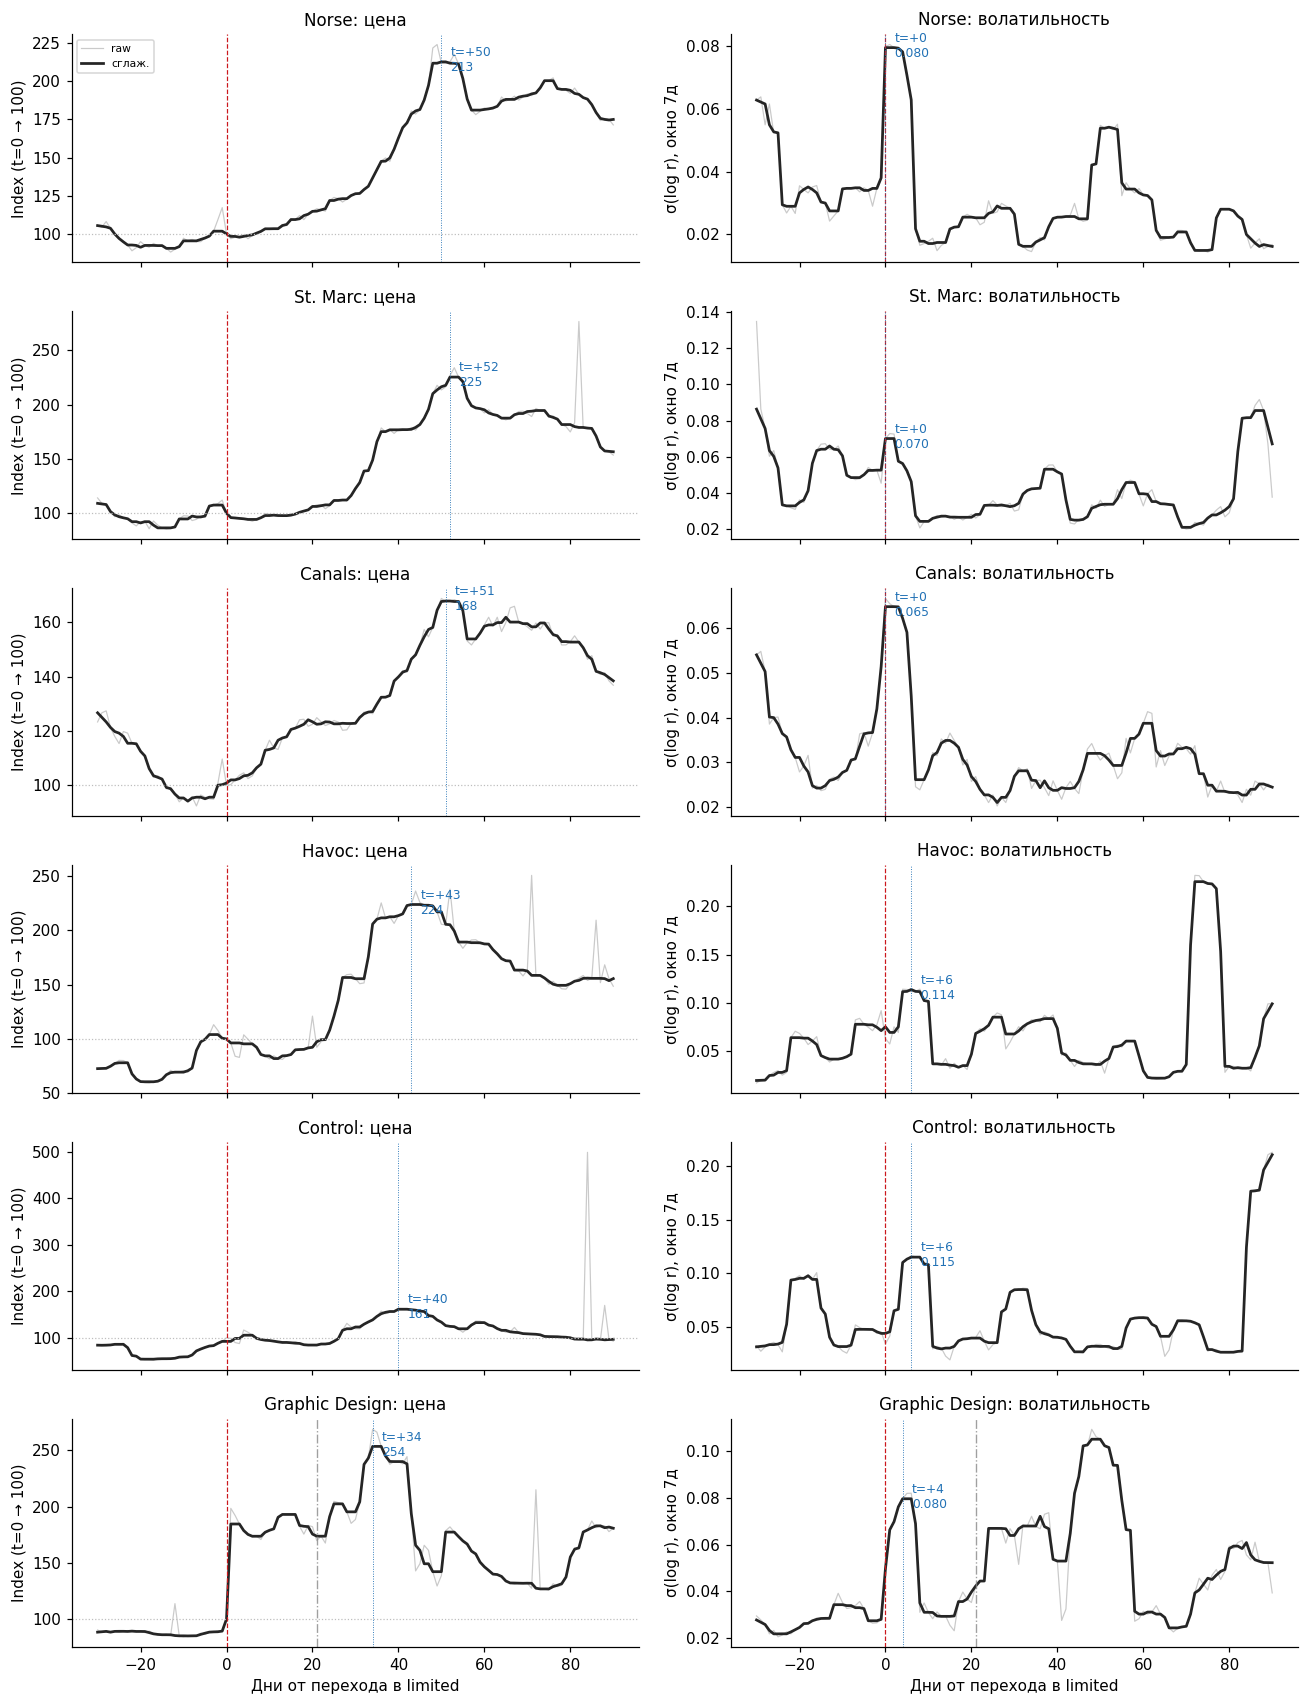

In [ ]:
def plot_per_collection(composites: Dict[str, pd.DataFrame], save: bool = True):
    n = len(composites)
    fig, axes = plt.subplots(n, 2, figsize=(12, 2.6 * n), sharex=True)
    if n == 1:
        axes = axes.reshape(1, -1)
    for i, (coll, c) in enumerate(composites.items()):
        pk = find_peaks(c)
        # Цена: сырой бледный + сглаженный жирный
        ax = axes[i, 0]
        ax.plot(c['event_day'], c['composite_price'], color='#bdbdbd', lw=0.8, alpha=0.8, label='raw')
        ax.plot(c['event_day'], c['composite_price_smooth'], color='#252525', lw=1.8, label='сглаж.')
        ax.axhline(100, color='#bdbdbd', lw=0.8, ls=':')
        ax.axvline(0, color='#cb181d', lw=0.8, ls='--')
        sec = SECONDARY_MARKERS.get(coll)
        if sec is not None:
            ax.axvline(sec, color='#888888', lw=0.9, ls='-.', alpha=0.8, label='удаление')
        if not np.isnan(pk.get('peak_price_day', np.nan)):
            d, v = pk['peak_price_day'], pk['peak_price_idx']
            ax.axvline(d, color='#2171b5', lw=0.6, ls=':')
            ax.annotate(f't={d:+d}\n{v:.0f}', xy=(d, v), xytext=(6, -6),
                        textcoords='offset points', fontsize=8, color='#2171b5')
        ax.set_ylabel('Index (t=0 → 100)')
        ax.set_title(f'{coll}: цена')
        if i == 0:
            ax.legend(fontsize=7, loc='upper left')
        # Воля
        ax = axes[i, 1]
        ax.plot(c['event_day'], c['composite_vol'], color='#bdbdbd', lw=0.8, alpha=0.8)
        ax.plot(c['event_day'], c['composite_vol_smooth'], color='#252525', lw=1.8)
        ax.axvline(0, color='#cb181d', lw=0.8, ls='--')
        if sec is not None:
            ax.axvline(sec, color='#888888', lw=0.9, ls='-.', alpha=0.8)
        if not np.isnan(pk.get('peak_vol_day', np.nan)):
            d, v = pk['peak_vol_day'], pk['peak_vol_value']
            ax.axvline(d, color='#2171b5', lw=0.6, ls=':')
            ax.annotate(f't={d:+d}\n{v:.3f}', xy=(d, v), xytext=(6, -6),
                        textcoords='offset points', fontsize=8, color='#2171b5')
        ax.set_ylabel(f'σ(log r), окно {VOL_WINDOW}д')
        ax.set_title(f'{coll}: волатильность')
        if i == n - 1:
            axes[i, 0].set_xlabel('Дни от перехода в limited')
            axes[i, 1].set_xlabel('Дни от перехода в limited')
    plt.tight_layout()
    if save:
        plt.savefig('per_collection.png', bbox_inches='tight')
    plt.show()


plot_per_collection(composites)


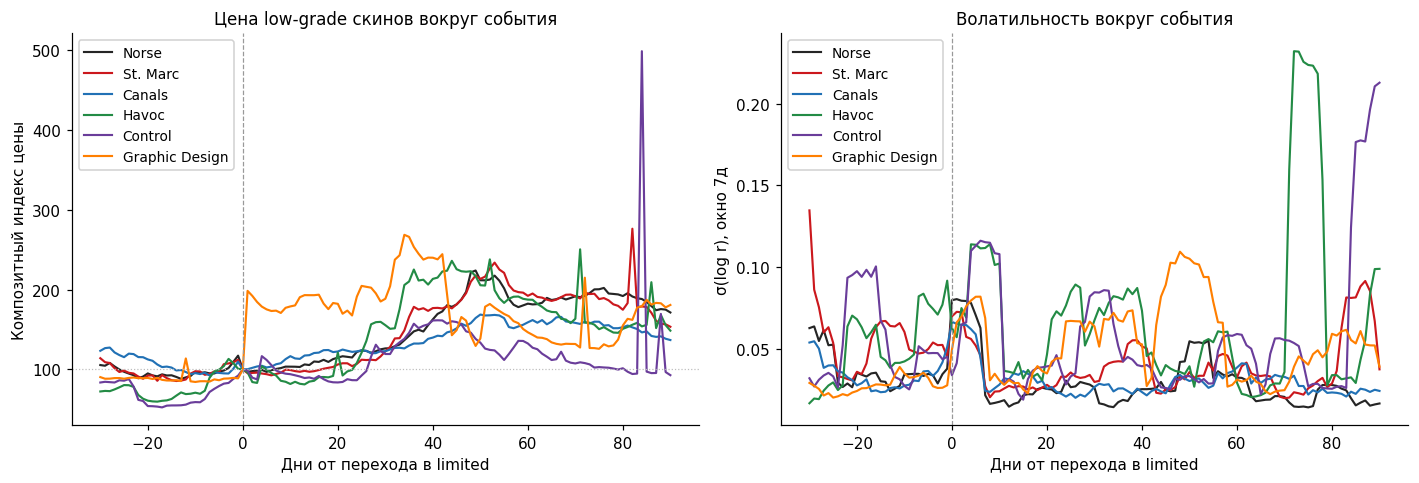

In [ ]:
# Cross-collection: все индексы на одной оси
def plot_cross_collection(composites: Dict[str, pd.DataFrame], save: bool = True):
    colors = ['#252525', '#cb181d', '#2171b5', '#238b45', '#6a3d9a', '#ff7f00']
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # 5.A Цена
    ax = axes[0]
    for (coll, c), col in zip(composites.items(), colors):
        ax.plot(c['event_day'], c['composite_price'], label=coll, color=col, lw=1.4)
    ax.axhline(100, color='#bdbdbd', lw=0.8, ls=':')
    ax.axvline(0, color='#999999', lw=0.8, ls='--')
    ax.set_xlabel('Дни от перехода в limited')
    ax.set_ylabel('Композитный индекс цены')
    ax.set_title('Цена low-grade скинов вокруг события')
    ax.legend(loc='upper left', framealpha=0.9)

    # 5.B Волатильность
    ax = axes[1]
    for (coll, c), col in zip(composites.items(), colors):
        ax.plot(c['event_day'], c['composite_vol'], label=coll, color=col, lw=1.4)
    ax.axvline(0, color='#999999', lw=0.8, ls='--')
    ax.set_xlabel('Дни от перехода в limited')
    ax.set_ylabel(f'σ(log r), окно {VOL_WINDOW}д')
    ax.set_title('Волатильность вокруг события')
    ax.legend(loc='upper left', framealpha=0.9)

    plt.tight_layout()
    if save:
        plt.savefig('cross_collection.png', bbox_inches='tight')
    plt.show()


plot_cross_collection(composites)


## 6. Поиск пиков и сводная таблица

Для каждой коллекции:
- День пика цены: `argmax` **сглаженного** композита (скользящая медиана `SMOOTH_WINDOW`) на днях с объёмом `>= MIN_DAILY_VOL`
- Амплитуда пика: `peak - 100` (рост в п.п. от базы)
- День пика волы: `argmax` сглаженной волатильности **в окне `VOL_PEAK_WINDOW`** (по умолчанию [0,+14]) - event-локальный отклик, а не посторонние поздние волатильные эпизоды
- Baseline volatility: медиана сглаженной волы на `[-30, -5]`
- Vol amplification: `vol[event-peak] / baseline`

**Три фикса против артефактов тонкого рынка** (по итогам первого прогона):
1. *Сглаживание*: пик берём по скользящей медиане, а не по сырому ряду - однодневные иглы (St. Marc +82, Graphic Design +51) больше не выдаются за пик.
2. *Volume-фильтр*: дни с суммарным объёмом коллекции ниже порога исключаются из поиска экстремума - именно на них сидят глитчи прайс-хистори.
3. *Винзоризация* (раздел 3): хвосты лог-доходностей клиппятся до расчёта волатильности.

Фазы пика цены: anticipation `[-30,-1]`, event_day `0`, short_post `[1,14]`, medium_post `[15,45]`, long_post `[46,90]`.


In [ ]:
# Функция find_peaks определена выше (в разделе помощников перед визуализацией).
# Здесь только собираем сводную таблицу по всем коллекциям.

rows = []
for coll, c in composites.items():
    anchor = 'анонс' if coll in SECONDARY_MARKERS else 'удаление'
    row = {'collection': coll, 'event_date': EVENT_DATES_EFF[coll].date(), 'anchor': anchor}
    row.update(find_peaks(c))
    rows.append(row)

summary = pd.DataFrame(rows).set_index('collection')
print(summary.to_string())
summary.to_csv('event_study_summary.csv')


                event_date    anchor  peak_price_day  peak_price_idx  peak_price_pp peak_price_phase  peak_vol_day  peak_vol_value  baseline_vol  vol_amplification
collection                                                                                                                                                         
Norse           2020-03-31  удаление              50           212.7          112.7        long_post             0          0.0796        0.0343               2.32
St. Marc        2020-03-31  удаление              52           225.3          125.3        long_post             0          0.0700        0.0551               1.27
Canals          2020-03-31  удаление              51           167.8           67.8        long_post             0          0.0648        0.0309               2.09
Havoc           2021-04-30  удаление              43           223.8          123.8      medium_post             6          0.1138        0.0436               2.61
Control         

## 7. Cross-collection статистика: робастна ли картина?

С 6 коллекциями полноценный inference невозможен (мощность около нуля), но базовые описательные оценки + bootstrap CI - полезны для понимания диапазона.

Что считаем:
- **Медиана дня пика цены** по 6 коллекциям + 95% bootstrap CI (1000 рекомбинаций).
- **Медиана дня пика волы** + CI.
- **Cumulative abnormal return (CAR)** на разных горизонтах: [0, +7], [0, +30], [0, +90] - если пик типично post-event, мы должны видеть монотонное накопление.


In [ ]:
def bootstrap_ci(values, n_boot=2000, alpha=0.05):
    values = np.array([v for v in values if not np.isnan(v)])
    if len(values) < 2:
        return (np.nan, np.nan)
    rng = np.random.default_rng(42)
    samples = rng.choice(values, size=(n_boot, len(values)), replace=True)
    meds = np.median(samples, axis=1)
    return float(np.quantile(meds, alpha/2)), float(np.quantile(meds, 1-alpha/2))


price_days = summary['peak_price_day'].values
vol_days = summary['peak_vol_day'].values

print(f'\nМедианный день пика ЦЕНЫ:  t = {np.median(price_days):+.1f}  '
      f'95% CI {bootstrap_ci(price_days)}')
print(f'Медианный день пика ВОЛЫ:  t = {np.median(vol_days):+.1f}  '
      f'95% CI {bootstrap_ci(vol_days)}')

# CAR на горизонтах
def car_at(comp: pd.DataFrame, h: int) -> float:
    end = comp[(comp['event_day'] >= 0) & (comp['event_day'] <= h)]
    if len(end) == 0:
        return np.nan
    # log return от t=0 до t=h
    end_val = end.iloc[-1]['composite_price']
    return float(np.log(end_val / 100.0))

car_rows = []
for coll, c in composites.items():
    car_rows.append({
        'collection': coll,
        'CAR[0,+7]':  round(car_at(c, 7), 3),
        'CAR[0,+30]': round(car_at(c, 30), 3),
        'CAR[0,+90]': round(car_at(c, 90), 3),
    })
car_df = pd.DataFrame(car_rows).set_index('collection')
print('\nCumulative log-returns от t=0:')
print(car_df.to_string())

# Кросс-коллекционная медиана CAR
print('\nМедиана по коллекциям:')
for h in ['CAR[0,+7]', 'CAR[0,+30]', 'CAR[0,+90]']:
    vals = car_df[h].values
    med = np.median(vals)
    ci = bootstrap_ci(vals)
    print(f'  {h}: median = {med:+.3f}  95% CI [{ci[0]:+.3f}, {ci[1]:+.3f}]   (e^median = {math.exp(med):.2f}x)')



Медианный день пика ЦЕНЫ:  t = +46.5  95% CI (37.0, 51.5)
Медианный день пика ВОЛЫ:  t = +2.0  95% CI (0.0, 6.0)

Cumulative log-returns от t=0:
                CAR[0,+7]  CAR[0,+30]  CAR[0,+90]
collection                                       
Norse               0.005       0.234       0.539
St. Marc           -0.059       0.204       0.428
Canals              0.062       0.205       0.313
Havoc              -0.080       0.441       0.396
Control            -0.014       0.176      -0.075
Graphic Design      0.552       0.634       0.592

Медиана по коллекциям:
  CAR[0,+7]: median = -0.005  95% CI [-0.070, +0.307]   (e^median = 1.00x)
  CAR[0,+30]: median = +0.220  95% CI [+0.190, +0.537]   (e^median = 1.25x)
  CAR[0,+90]: median = +0.412  95% CI [+0.119, +0.566]   (e^median = 1.51x)


## 8. Итоговый сравнительный график

Один рисунок 2x2:
- (1,1) Все 6 индексов цены на event-time
- (1,2) Все 6 волатильностей на event-time
- (2,1) День пика цены по коллекциям (точки + медиана)
- (2,2) Vol amplification по коллекциям (peak/baseline)


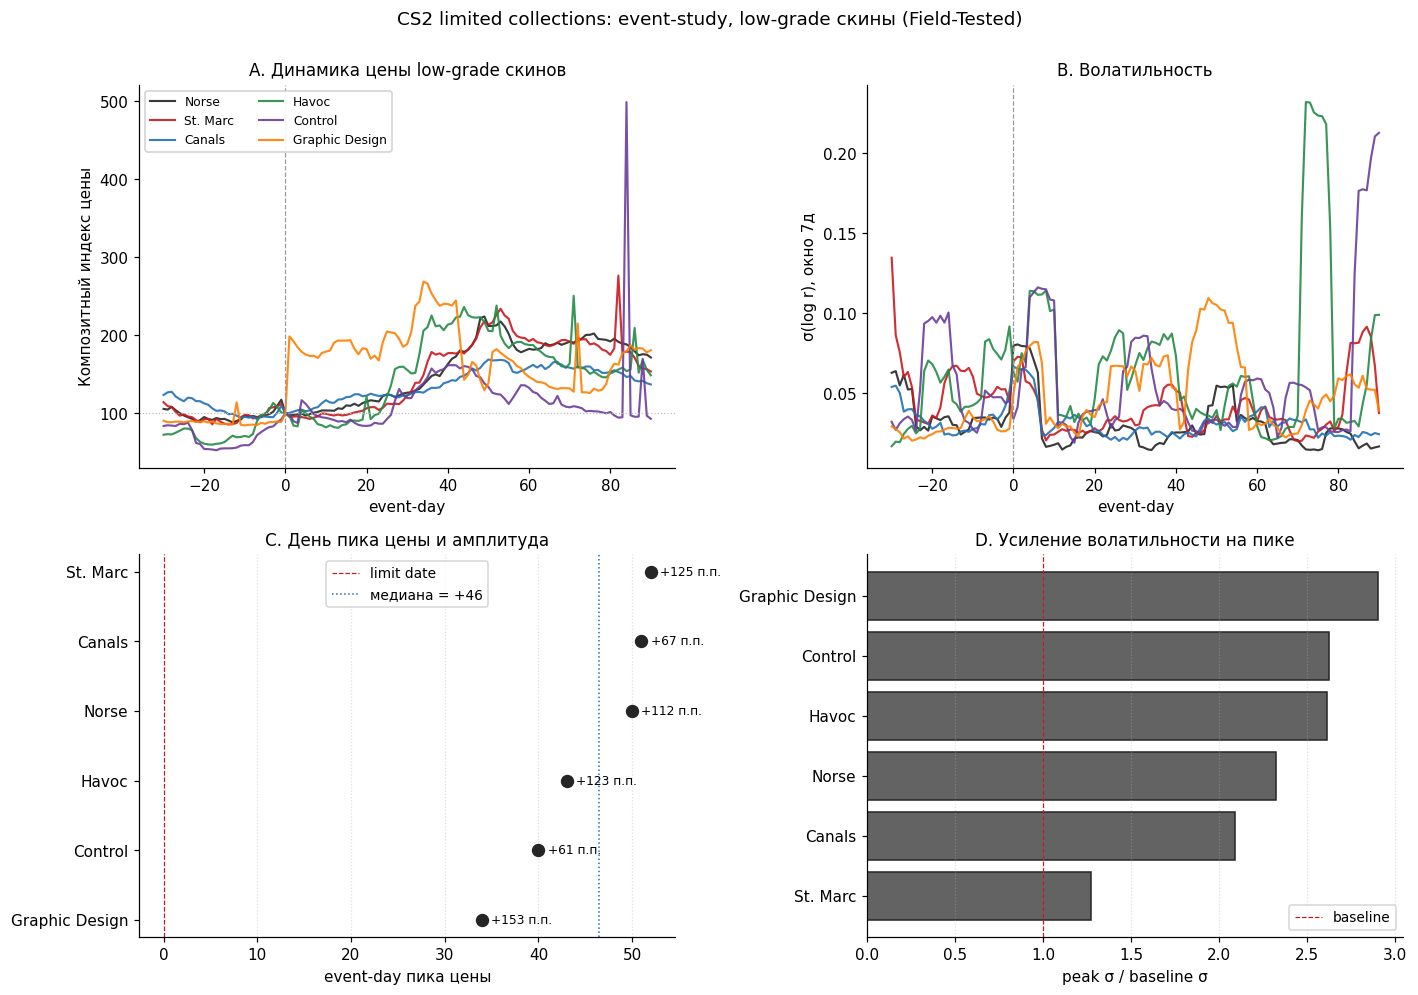

In [ ]:
def final_plot(composites, summary, save=True):
    colors = ['#252525', '#cb181d', '#2171b5', '#238b45', '#6a3d9a', '#ff7f00']
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # (1,1) Цены
    ax = axes[0, 0]
    for (coll, c), col in zip(composites.items(), colors):
        ax.plot(c['event_day'], c['composite_price'], label=coll, color=col, lw=1.4, alpha=0.9)
    ax.axhline(100, color='#bdbdbd', lw=0.8, ls=':')
    ax.axvline(0, color='#999999', lw=0.8, ls='--')
    ax.set_xlabel('event-day')
    ax.set_ylabel('Композитный индекс цены')
    ax.set_title('A. Динамика цены low-grade скинов')
    ax.legend(loc='best', framealpha=0.9, ncol=2, fontsize=8)

    # (1,2) Воля
    ax = axes[0, 1]
    for (coll, c), col in zip(composites.items(), colors):
        ax.plot(c['event_day'], c['composite_vol'], label=coll, color=col, lw=1.4, alpha=0.9)
    ax.axvline(0, color='#999999', lw=0.8, ls='--')
    ax.set_xlabel('event-day')
    ax.set_ylabel(f'σ(log r), окно {VOL_WINDOW}д')
    ax.set_title('B. Волатильность')

    # (2,1) День пика цены по коллекциям
    ax = axes[1, 0]
    s = summary.sort_values('peak_price_day')
    y = np.arange(len(s))
    ax.scatter(s['peak_price_day'], y, color='#252525', s=60, zorder=3)
    for i, (idx, row) in enumerate(s.iterrows()):
        ax.annotate(f'+{int(row["peak_price_pp"])} п.п.', xy=(row['peak_price_day'], i),
                    xytext=(6, 0), textcoords='offset points', fontsize=8, va='center')
    ax.axvline(0, color='#cb181d', lw=0.8, ls='--', label='limit date')
    ax.axvline(np.median(s['peak_price_day']), color='#2171b5', lw=1.0, ls=':', label=f'медиана = {np.median(s["peak_price_day"]):+.0f}')
    ax.set_yticks(y)
    ax.set_yticklabels(s.index)
    ax.set_xlabel('event-day пика цены')
    ax.set_title('C. День пика цены и амплитуда')
    ax.legend()
    ax.grid(axis='x', ls=':', alpha=0.4)

    # (2,2) Vol amplification
    ax = axes[1, 1]
    s2 = summary.dropna(subset=['vol_amplification']).sort_values('vol_amplification')
    y2 = np.arange(len(s2))
    ax.barh(y2, s2['vol_amplification'], color='#636363', edgecolor='#252525')
    ax.axvline(1, color='#cb181d', lw=0.8, ls='--', label='baseline')
    ax.set_yticks(y2)
    ax.set_yticklabels(s2.index)
    ax.set_xlabel('peak σ / baseline σ')
    ax.set_title('D. Усиление волатильности на пике')
    ax.legend()
    ax.grid(axis='x', ls=':', alpha=0.4)

    plt.suptitle('CS2 limited collections: event-study, low-grade скины ({})'.format(WEAR), y=1.0, fontsize=12)
    plt.tight_layout()
    if save:
        plt.savefig('event_study_final.png', bbox_inches='tight', dpi=160)
    plt.show()


final_plot(composites, summary)


Файлы на выходе:
- `cs2_cache/*.json` - сырые ответы Steam
- `per_collection.png`, `cross_collection.png`, `event_study_final.png`
- `event_study_summary.csv` - таблица пиков
